In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel("D:\Data Scientist 30L\OLA_Ride_Insights\Data\OLA_DataSet.xlsx")

In [5]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


In [6]:
df.shape

(103024, 20)

In [7]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[us]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  str           
 3   Booking_Status              103024 non-null  str           
 4   Customer_ID                 103024 non-null  str           
 5   Vehicle_Type                103024 non-null  str           
 6   Pickup_Location             103024 non-null  str           
 7   Drop_Location               103024 non-null  str           
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   str           
 11  Canceled_Rides_by_Driver    18434 non-null   str  

In [9]:
df.isnull().sum()

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                39057
Customer_Rating               39057
Vehicle Images                    0
dtype: int64

In [10]:
df.describe()

,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,103024,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000
mean,2024-07-16 11:31:38.879678,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313
min,2024-07-01 00:00:00,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000
25%,2024-07-08 18:41:00,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000
50%,2024-07-16 11:23:00,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000
75%,2024-07-24 05:18:00,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000
max,2024-07-31 23:58:00,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000
std,NaN,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df_clean = df.copy()

In [13]:
df_clean["Day"]=df_clean['Date'].dt.day_name()
df_clean["Month"]=df_clean['Date'].dt.month_name()
df_clean["Weekday_number"]=df_clean['Date'].dt.weekday

In [14]:
df_clean[['Date','Day','Month']].head()

,Date,Day,Month
0,2024-07-26 14:00:00,Friday,July
1,2024-07-25 22:20:00,Thursday,July
2,2024-07-30 19:59:00,Tuesday,July
3,2024-07-22 03:15:00,Monday,July
4,2024-07-02 09:02:00,Tuesday,July


In [15]:
df_clean['Time'] = pd.to_datetime(
    df_clean['Time'].astype(str)
)

C:\Users\dealb\AppData\Local\Temp\ipykernel_18572\3843975334.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Time'] = pd.to_datetime(


In [16]:
df_clean['Hour'] = df_clean['Time'].dt.hour

In [17]:

df_clean[['Time','Hour']].head()

,Time,Hour
0,2026-06-09 14:00:00,14
1,2026-06-09 22:20:00,22
2,2026-06-09 19:59:00,19
3,2026-06-09 03:15:00,3
4,2026-06-09 09:02:00,9


In [18]:
df_clean['Revenue_Category'] = pd.cut(
    df_clean['Booking_Value'],
    bins=[0,300,700,3000],
    labels=['Low','Medium','High']
)

In [19]:
df_clean['Revenue_Category'].value_counts()

Revenue_Category
Medium    44585
Low       36132
High      22307
Name: count, dtype: int64

In [20]:
df_clean['Success_Flag'] = np.where(
    df_clean['Booking_Status']=='Success',
    1,
    0
)

In [21]:
df_clean['Success_Flag'].value_counts()

Success_Flag
1    63967
0    39057
Name: count, dtype: int64

In [22]:
df_clean['Cancellation_Flag'] = np.where(
    df_clean['Booking_Status'].str.contains('Canceled'),
    1,
    0
)

In [23]:
df_clean['Cancellation_Flag'].value_counts()

Cancellation_Flag
0    74091
1    28933
Name: count, dtype: int64

In [24]:
df_clean.to_csv(
    "OLA_Cleaned.csv",
    index=False
)

In [25]:
hourly_bookings = (
    df_clean.groupby('Hour')
    .size()
    .reset_index(name='Bookings')
)

hourly_bookings

,Hour,Bookings
0,0,4318
1,1,4329
2,2,4305
3,3,4201
4,4,4263
5,5,4264
6,6,4271
7,7,4304
8,8,4374
9,9,4347


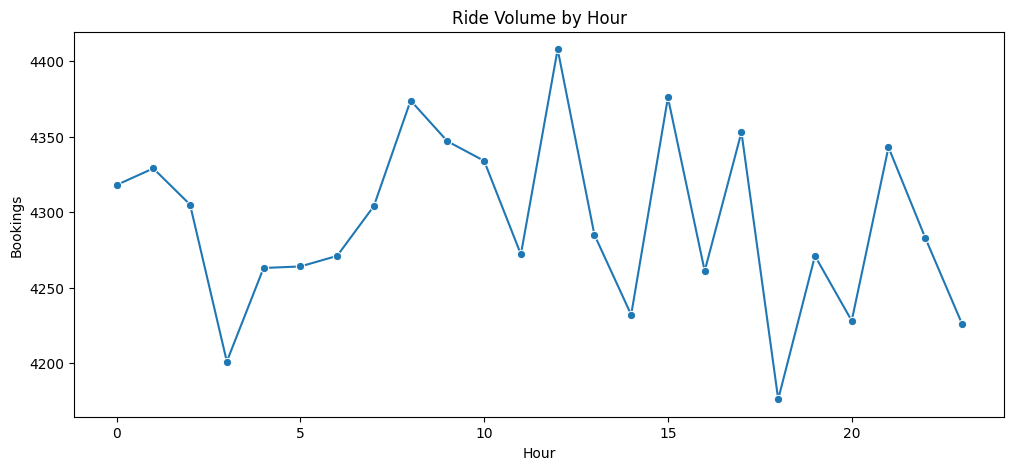

In [26]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_bookings,
    x='Hour',
    y='Bookings',
    marker='o'
)

plt.title("Ride Volume by Hour")
plt.show()

In [27]:
df_clean['Booking_Status'].value_counts()

Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64

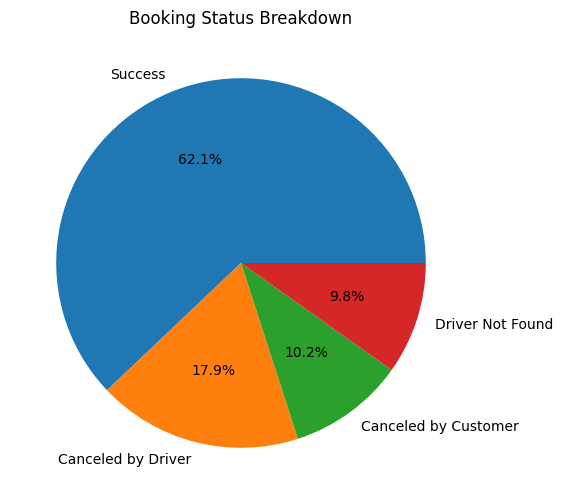

In [28]:
status = df_clean['Booking_Status'].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    status.values,
    labels=status.index,
    autopct='%1.1f%%'
)

plt.title("Booking Status Breakdown")
plt.show()

In [29]:
vehicle_revenue = (
    df_clean.groupby('Vehicle_Type')
    ['Booking_Value']
    .sum()
    .sort_values(ascending=False)
)

vehicle_revenue

Vehicle_Type
Prime Sedan    8298612
eBike          8181523
Auto           8092210
Prime Plus     8050889
Mini           7990996
Bike           7987054
Prime SUV      7933330
Name: Booking_Value, dtype: int64

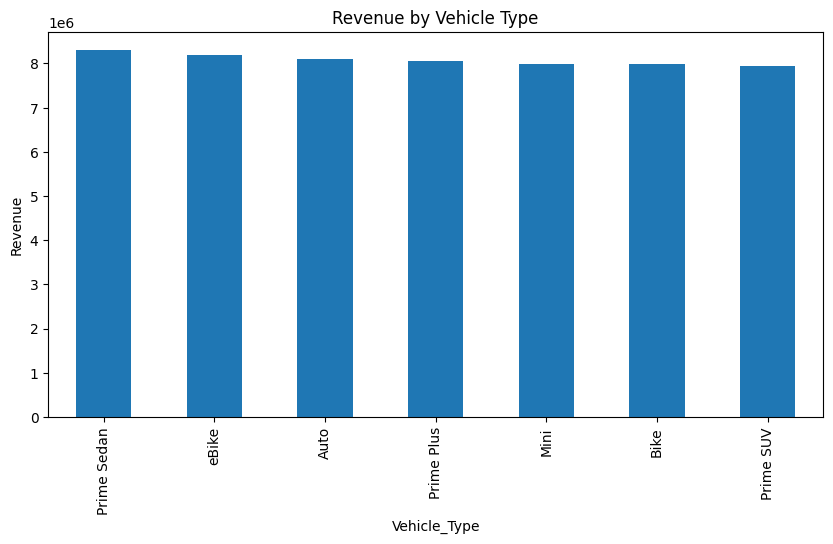

In [30]:
plt.figure(figsize=(10,5))

vehicle_revenue.plot(kind='bar')

plt.title("Revenue by Vehicle Type")
plt.ylabel("Revenue")
plt.show()

In [31]:
ratings = (
    df_clean.groupby('Vehicle_Type')
    ['Customer_Rating']
    .mean()
    .sort_values(ascending=False)
)

ratings

Vehicle_Type
Prime Plus     4.009499
Prime Sedan    4.001589
Prime SUV      3.999378
Auto           3.998811
Mini           3.997731
Bike           3.993376
eBike          3.987854
Name: Customer_Rating, dtype: float64

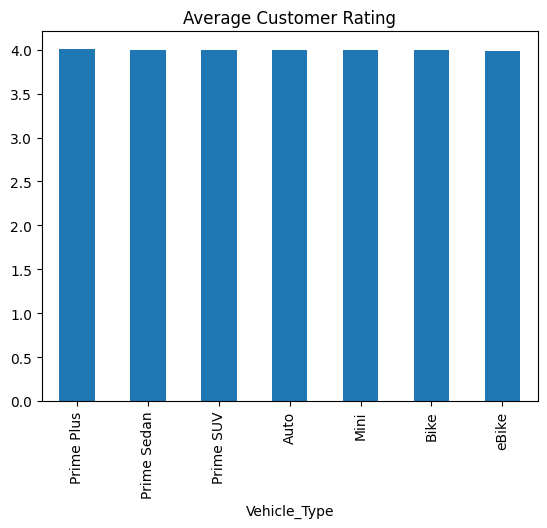

In [32]:
ratings.plot(kind='bar')
plt.title("Average Customer Rating")
plt.show()

In [33]:
df_clean['Payment_Method'].value_counts()

Payment_Method
Cash           35022
UPI            25881
Credit Card     2435
Debit Card       629
Name: count, dtype: int64

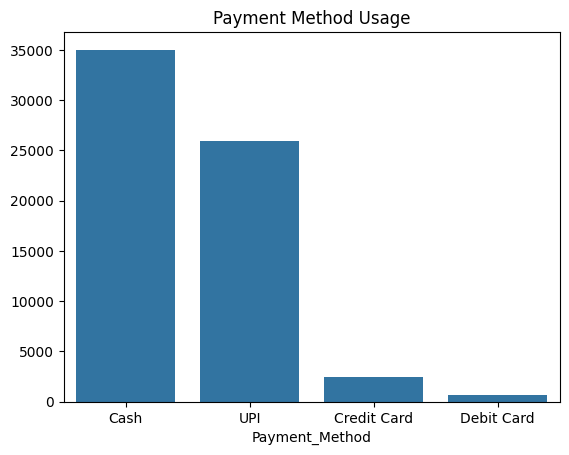

In [34]:
payment = df_clean['Payment_Method'].value_counts()

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Payment Method Usage")
plt.show()

In [35]:
df_clean['DateTime'] = pd.to_datetime(
    df_clean['Date'].astype(str) + ' ' +
    df_clean['Time'].dt.strftime('%H:%M:%S')
)

C:\Users\dealb\AppData\Local\Temp\ipykernel_18572\738147618.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['DateTime'] = pd.to_datetime(


In [36]:
df_clean[['DateTime']].head()

,DateTime
0,2024-07-26 14:00:00
1,2024-07-25 22:20:00
2,2024-07-30 19:59:00
3,2024-07-22 03:15:00
4,2024-07-02 09:02:00


In [37]:
df_clean.to_csv(
    "OLA_Cleaned.csv",
    index=False
)

In [38]:
df_clean = df_clean.drop(columns=['Vehicle Images'])

In [39]:
df_clean['Revenue_Category'] = df_clean['Revenue_Category'].astype(str)

In [40]:
df_clean.dtypes

Date                          datetime64[us]
Time                          datetime64[us]
Booking_ID                               str
Booking_Status                           str
Customer_ID                              str
Vehicle_Type                             str
Pickup_Location                          str
Drop_Location                            str
V_TAT                                float64
C_TAT                                float64
Canceled_Rides_by_Customer               str
Canceled_Rides_by_Driver                 str
Incomplete_Rides                         str
Incomplete_Rides_Reason                  str
Booking_Value                          int64
Payment_Method                           str
Ride_Distance                          int64
Driver_Ratings                       float64
Customer_Rating                      float64
Day                                      str
Month                                    str
Weekday_number                         int32
Hour      

In [41]:
df_sql = df_clean.copy()

# Fill numeric nulls
df_sql['V_TAT'] = df_sql['V_TAT'].fillna(0)
df_sql['C_TAT'] = df_sql['C_TAT'].fillna(0)
df_sql['Driver_Ratings'] = df_sql['Driver_Ratings'].fillna(0)
df_sql['Customer_Rating'] = df_sql['Customer_Rating'].fillna(0)

# Fill text nulls
text_cols = [
    'Canceled_Rides_by_Customer',
    'Canceled_Rides_by_Driver',
    'Incomplete_Rides',
    'Incomplete_Rides_Reason',
    'Payment_Method'
]

for col in text_cols:
    df_sql[col] = df_sql[col].fillna('N/A')

df_sql.to_csv("OLA_SQL.csv", index=False)

In [42]:
df_sql.columns


Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Day', 'Month', 'Weekday_number', 'Hour', 'Revenue_Category',
       'Success_Flag', 'Cancellation_Flag', 'DateTime'],
      dtype='str')